In [ ]:
# %load_ext autoreload
# %autoreload 2

# from tdm.utils import microns
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from tdm.style import RESPONSE_COLOR, NO_RESPONSE_COLOR
# from tdm.model import Model
# from tdm.numerical.phase_portrait_analysis import get_nullclines


# import numpy as np


# def compute_change_in_each_direction(
#     f,
#     xlim: tuple[float, float],
#     ylim: tuple[float, float], 
#     step: float = 0.01,
# ):
#     """
#     Computes rates of change dx/dt and dy/dt over a grid of x,y values
#     within the range xlim and ylim, for any function f(x,y) that returns dx/dt, dy/dt.

#     Args:
#         f: Function that takes two scalar inputs x,y and returns two scalar outputs dx/dt, dy/dt
#         xlim: (xmin, xmax) tuple defining x range
#         ylim: (ymin, ymax) tuple defining y range
#         step: Grid spacing

#     Returns:
#         (X, Y, dXdt, dYdt): Tuple of meshgrids of shape (xlim / step) x (ylim / step)
#     """
#     # Create uniform grid of x,y values
#     X = np.arange(*xlim, step=step)
#     Y = np.arange(*ylim, step=step)
#     X, Y = np.meshgrid(X, Y)

#     # Calculate derivatives at each point
#     dXdt = np.zeros_like(X)
#     dYdt = np.zeros_like(Y)
    
#     for i in range(X.shape[0]):
#         for j in range(X.shape[1]):
#             dXdt[i,j], dYdt[i,j] = f(X[i,j], Y[i,j])

#     return X, Y, dXdt, dYdt

# def plot_phase_portrait(f, xlim, ylim, plot_a=True, plot_b=True, linewidth=1, step=0.01, xlabel='', ylabel=''):

#     x, y, u, v = compute_change_in_each_direction(f, xlim, ylim, step)


#     fig, ax = plt.subplots(figsize=(5, 5))

#     ax.streamplot(
#         x,
#         y,
#         u,
#         v,
#         broken_streamlines=True,
#         color=RESPONSE_COLOR,
#         density=0.5,
#         linewidth=2,
#     )

#     a_nullclines, b_nullclines = get_nullclines(x, y, u, v)

#     if plot_a:
#         for g in a_nullclines.geoms:
#             x, y = g.xy
#             ax.plot(x, y, color=BLUE, linewidth=linewidth)

#     if plot_b:
#         for g in b_nullclines.geoms:
#             x, y = g.xy
#             ax.plot(x, y, color=RED, linewidth=linewidth)

    

#     ax.set_xlim(xlim)
#     ax.set_ylim(ylim)

#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)

#     return fig, ax

: 

In [37]:
import control as ct
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

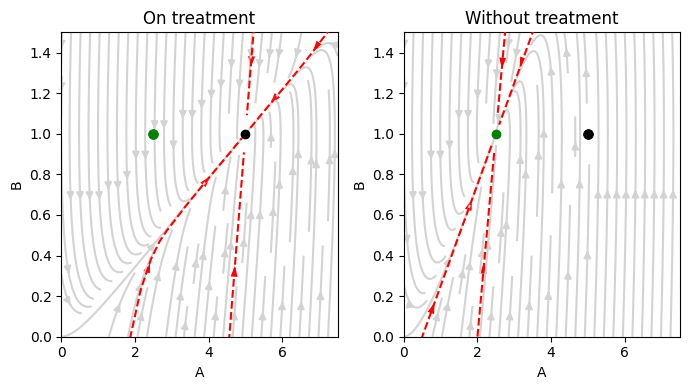

In [101]:

def sys_update(t, x, u, params):

    gamma = params['gamma']
    A,B = x

    dA = gamma*(1-B)
    dB = A-B

    return dA, dB

def sys_update(t, x, u, params):

    a1, b1, b2 = [params[p] for p in ['a1', 'b1', 'b2'] ]
    A,B = x

    dA = a1*(1-B)
    dB = b1*A-b2*B

    return dA, dB


a1 = 1
b1 = 1
b2 = 2.5

Bsd = 1
Asd = b2/b1

b1_on_treatment = b1 / 2
Asd_on_treatment = b2 / b1_on_treatment

r = 1.5
xlim = Asd_on_treatment*r
ylim=Bsd * r
axis_limits = [0, xlim, 0, ylim]

fig, axs = plt.subplots(figsize=(7,4), ncols=2)

ax = axs[0]
sys = ct.nlsys(
    sys_update, states=['A', 'B'], params={'a1':a1, 'b1':b1_on_treatment, 'b2':b2},
    name='integral feedback model')
ct.phase_plane_plot(sys, axis_limits, ax=ax, plot_streamplot={'color':'lightgray'}, plot_equilpoints={'color': 'black'})
sns.scatterplot(x=[Asd], y=[Bsd], zorder=100, color='green', edgecolor='green', s=50, ax=ax)
ax.set_title('On treatment')


ax = axs[1]
sys = ct.nlsys(
    sys_update, states=['A', 'B'], params={'a1':a1, 'b1':b1, 'b2':b2},
    name='integral feedback model')

ct.phase_plane_plot(sys, axis_limits, ax=ax, plot_streamplot={'color':'lightgray'}, plot_equilpoints={'color': 'green'})
sns.scatterplot(x=[Asd_on_treatment], y=[Bsd], zorder=100, color='black', edgecolor='black', s=50, ax=ax)
ax.set_title('Without treatment')


for ax in axs:
    ax.set_xlabel('A')
    ax.set_ylabel('B')

fig.tight_layout()

# Numerical simulation of dimensionless A,B,C model:


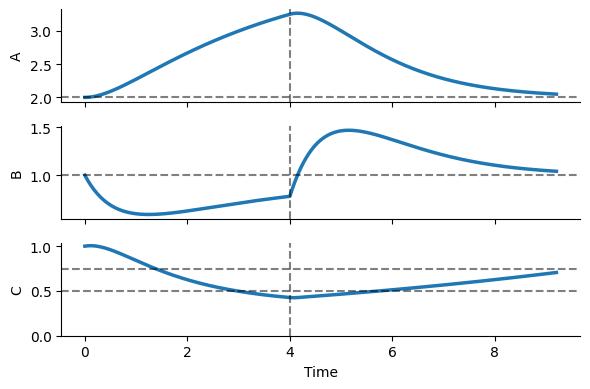

In [162]:
a1 = 1
b1 = 1
b2 = 2
mu = 1

rho1 = 1/20 # determines cancer growth rate
rho2 = 0.5 # determines cancer maximal removal rate relative to B recovery rate

c1 = rho1*b2
c2 = rho2*b2/mu

off_params = {
    'a1': a1, 
    'b1': b1, 
    'b2': b2, 
    'mu': mu, 
    'c1': c1, # rho1 = 1/10
    'c2': c2,  # rho2 = 4
}

on_params = {
    'a1': a1, 
    'b1': b1/2, 
    'b2': b2, 
    'mu': mu, 
    'c1': c1,
    'c2': c2,
}

B_off_ss = mu
A_off_ss = b2*mu/b1

def get_f(params):

    def f(t,x):
        a1, b1, b2, mu, c1, c2 = [params[p] for p in ['a1', 'b1', 'b2', 'mu', 'c1', 'c2']]
        A, B, C = x

        dA = a1*(mu-B)
        dB = b1*A-b2*B
        dC = C*(c1 - c2*max(mu-B,0))

        return dA, dB, dC
    
    return f

off_f = get_f(off_params)
on_f = get_f(on_params)


# use scipy.odeint to simulate on_f for a duration T = 10, starting from A_off, B_off_ss, and C=1
# then switch to off_f for another k*T duration
# plot A,B,C on different rows (axes) using fig.subplots
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

# Simulation parameters
T = 30
k = 0  # number of off cycles after on

T = 4
k = 1.3  # number of off cycles after on

t_on = np.linspace(0, T, 200)
t_off = np.linspace(0, k*T, 600)

# Initial conditions: A_off_ss, B_off_ss, C=1
x0 = [A_off_ss, B_off_ss, 1.0]

# Simulate ON phase
sol_on = odeint(lambda x, t: on_f(t, x), x0, t_on)
A_on, B_on, C_on = sol_on.T

# Use final state of ON as initial for OFF
x0_off = sol_on[-1]

# Simulate OFF phase
sol_off = odeint(lambda x, t: off_f(t, x), x0_off, t_off)
A_off, B_off, C_off = sol_off.T

# Concatenate time and solutions
t_total = np.concatenate([t_on, t_on[-1] + t_off])
A_total = np.concatenate([A_on, A_off])
B_total = np.concatenate([B_on, B_off])
C_total = np.concatenate([C_on, C_off])

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(6,4), sharex=True)

axes[0].plot(t_total, A_total, label='A', linewidth=2.5)
axes[0].set_ylabel('A')
axes[0].axvline(T, color='k', linestyle='--', alpha=0.5)
axes[0].axhline(A_off_ss, color='k', linestyle='--', alpha=0.5)


axes[1].plot(t_total, B_total, label='B', linewidth=2.5)
axes[1].set_ylabel('B')
axes[1].axvline(T, color='k', linestyle='--', alpha=0.5)
axes[1].axhline(B_off_ss, color='k', linestyle='--', alpha=0.5)


axes[2].plot(t_total, C_total, label='C', linewidth=2.5)
axes[2].set_ylabel('C')
axes[2].set_xlabel('Time')
axes[2].axvline(T, color='k', linestyle='--', alpha=0.5)
axes[2].set_ylim(bottom=0)
axes[2].axhline(0.5, color='k', linestyle='--', alpha=0.5)
axes[2].axhline(0.75, color='k', linestyle='--', alpha=0.5)

for ax in axes:
    sns.despine(ax=ax)
    

plt.tight_layout()
plt.show()


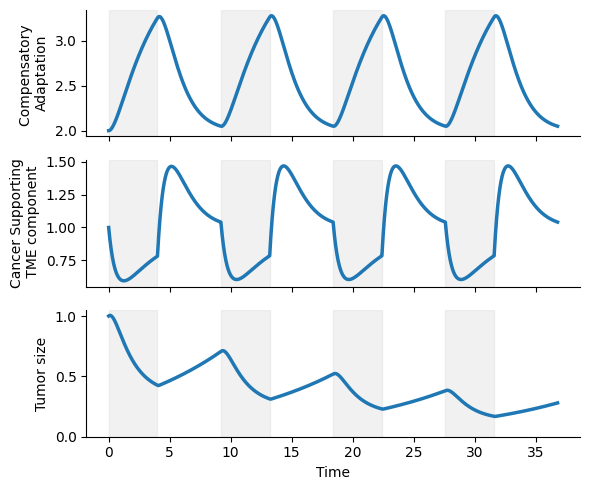

In [ ]:
# a1 = 1
# b1 = 1
# b2 = 2.5
# mu = 1

# rho1 = 1/35 # determines cancer growth rate
# rho2 = 1.1 # determines cancer removal rate under treatment

# c1 = rho1*b2
# c2 = rho2*b2/mu

# off_params = {
#     'a1': a1, 
#     'b1': b1, 
#     'b2': b2, 
#     'mu': mu, 
#     'c1': c1, # rho1 = 1/10
#     'c2': c2,  # rho2 = 4
# }

# on_params = {
#     'a1': a1, 
#     'b1': b1/2, 
#     'b2': b2, 
#     'mu': mu, 
#     'c1': c1,
#     'c2': c2,
# }

# B_off_ss = mu
# A_off_ss = b2*mu/b1

# def get_f(params):

#     def f(t,x):
#         a1, b1, b2, mu, c1, c2 = [params[p] for p in ['a1', 'b1', 'b2', 'mu', 'c1', 'c2']]
#         A, B, C = x

#         dA = a1*(mu-B)
#         dB = b1*A-b2*B
#         dC = C*(c1 - c2*max(mu-B,0))

#         return dA, dB, dC
    
#     return f

# off_f = get_f(off_params)
# on_f = get_f(on_params)

# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.integrate import odeint

# Simulation parameters
# T = 1
# k = 10  # number of off cycles after on
n_cycles = 4  # repeat the ON/OFF cycle 5 times

t_on = np.linspace(0, T, 200)
t_off = np.linspace(0, k*T, 600)

# Initial conditions: A_off_ss, B_off_ss, C=1
x0 = [A_off_ss, B_off_ss, 1.0]

# Prepare lists to accumulate results
t_total = []
A_total = []
B_total = []
C_total = []

t_last = 0
x_current = x0

for i in range(n_cycles):
    # Simulate ON phase
    sol_on = odeint(lambda x, t: on_f(t, x), x_current, t_on)
    A_on, B_on, C_on = sol_on.T
    t_on_shifted = t_last + t_on
    t_total.append(t_on_shifted)
    A_total.append(A_on)
    B_total.append(B_on)
    C_total.append(C_on)
    t_last = t_on_shifted[-1]
    x_current = sol_on[-1]

    # Simulate OFF phase
    sol_off = odeint(lambda x, t: off_f(t, x), x_current, t_off)
    A_off, B_off, C_off = sol_off.T
    t_off_shifted = t_last + t_off
    t_total.append(t_off_shifted)
    A_total.append(A_off)
    B_total.append(B_off)
    C_total.append(C_off)
    t_last = t_off_shifted[-1]
    x_current = sol_off[-1]

# Concatenate all results
t_total = np.concatenate(t_total)
A_total = np.concatenate(A_total)
B_total = np.concatenate(B_total)
C_total = np.concatenate(C_total)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(6,5), sharex=True)

axes[0].plot(t_total, A_total, label='A', linewidth=2.5)
axes[0].set_ylabel('Compensatory \nAdaptation')
# for i in range(n_cycles):
#     axes[0].axvline(i*(T + k*T) + T, color='k', linestyle='--', alpha=0.5)

axes[1].plot(t_total, B_total, label='B', linewidth=2.5)
axes[1].set_ylabel('Cancer Supporting\n TME component')
# for i in range(n_cycles):
#     axes[1].axvline(i*(T + k*T) + T, color='k', linestyle='--', alpha=0.5)

axes[2].plot(t_total, C_total, label='C', linewidth=2.5)
axes[2].set_ylabel('Tumor size')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)
# for i in range(n_cycles):
#     axes[2].axvline(i*(T + k*T) + T, color='k', linestyle='--', alpha=0.5)



# Add lightgray background during treatment (ON phase)
for i in range(n_cycles):
    t_start = i * (T + k*T)
    t_end = t_start + T
    for ax in axes:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.3, zorder=0)


for ax in axes:
    sns.despine(ax=ax)
    
plt.tight_layout()
plt.show()


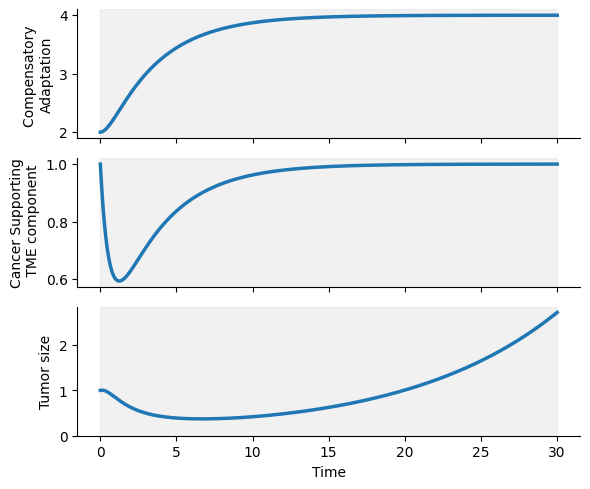

In [168]:
# Simulation parameters


# Simulate continuous treatment for 5*T steps
t_sim = np.linspace(0, 30, 1000)

# Initial conditions: A_off_ss, B_off_ss, C=1
x0 = [A_off_ss, B_off_ss, 1.0]

# Simulate ON phase only (continuous treatment)
sol_on = odeint(lambda x, t: on_f(t, x), x0, t_sim)
A_on, B_on, C_on = sol_on.T

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(6,5), sharex=True)

axes[0].plot(t_sim, A_on, label='A', linewidth=2.5)
axes[0].set_ylabel('Compensatory \nAdaptation')

axes[1].plot(t_sim, B_on, label='B', linewidth=2.5)
axes[1].set_ylabel('Cancer Supporting\n TME component')

axes[2].plot(t_sim, C_on, label='C', linewidth=2.5)
axes[2].set_ylabel('Tumor size')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

# add a lightgray background from 0 onwards:
for ax in axes:
    ax.axvspan(0, t_sim[-1], color='lightgray', alpha=0.3, zorder=0)


for ax in axes:
    sns.despine(ax=ax)
    
plt.tight_layout()
plt.show()


# Solving the treatment problem analytically 

In [44]:
import sympy as sp
from sympy.solvers.ode.systems import dsolve_system

# variables and parameters
t = sp.symbols('t')
A = sp.Function('A')(t)
B = sp.Function('B')(t)

# parameters
a1, b1, b2, mu = sp.symbols('a1 b1 b2 mu', positive=True)

# define ODE system
dA_dt = sp.Eq(A.diff(t), a1*(mu - B))
dB_dt = sp.Eq(B.diff(t), b1*A - b2*B)

# substitute parameter values
off_treatment_params = {a1: 1, mu: 1, b1:1, b2:2.5}
on_treatment_params = {a1: 1, mu: 1, b1:1/2, b2:2.5}

# solve system
sol = dsolve_system([dA_dt, dB_dt])

In [45]:
At_off = sol[0][0].subs(off_treatment_params).simplify().simplify()
At_on = sol[0][0].subs(on_treatment_params).simplify().simplify()

Bt_off = sol[0][1].subs(off_treatment_params).simplify().simplify()
Bt_on = sol[0][1].subs(on_treatment_params).simplify().simplify()

In [46]:
At_off

Eq(A(t), 0.5*C1*exp(-2.0*t) + 2.0*C2*exp(-0.5*t) + 2.5)

In [47]:
Bt_off

Eq(B(t), 1.0*C1*exp(-2.0*t) + 1.0*C2*exp(-0.5*t) + 1.0)

In [48]:
At_on

Eq(A(t), 0.43844718719117*C1*exp(-2.28077640640442*t) + 4.56155281280883*C2*exp(-0.219223593595585*t) + 5.0)

In [49]:
Bt_on

Eq(B(t), 1.0*C1*exp(-2.28077640640442*t) + 1.0*C2*exp(-0.219223593595585*t) + 1.0)

In [50]:
# start from off_treatment steady state:
A_off_ss = A0 = (b2 * mu / b1).subs(off_treatment_params)
B_off_ss = B0 = mu.subs(off_treatment_params)

def get_C1_C2(At,Bt, A0, B0):

    eqs = [
        sp.Eq(At.rhs.subs(t,0), A0),
        sp.Eq(Bt.rhs.subs(t,0), B0)
    ]

    return sp.solve(eqs)

Cs = get_C1_C2(At_on, Bt_on, A0, B0)

In [51]:
Cs

{C1: 0.606339062590832, C2: -0.606339062590832}

In [52]:
At_on = At_on.subs(Cs)
Bt_on = Bt_on.subs(Cs)

## This is the first "challenging" computation:

In [53]:
T = sp.symbols('T', positive=True)
integral_of_B_from_zero_to_T_on_treatment = sp.integrate(Bt_on.rhs, (t, 0, T))
integral_of_B_from_zero_to_T_on_treatment

1.0*T - 2.5 - 0.265847656477081*exp(-2.28077640640442*T) + 2.76584765647708*exp(-0.219223593595585*T)

## Now we solve the off-treatment part:

In [54]:
# initial points for off-treatment part:
Tval = {T: 1}
AT = At_on.subs(t,T).subs(Tval).rhs
BT = Bt_on.subs(t,T).subs(Tval).rhs


In [ ]:
# off_treatment solution from AT, BT
Cs = get_C1_C2(At_off, Bt_off, AT, BT)
At_off = At_off.subs(Cs)
Bt_off = Bt_off.subs(Cs)

In [58]:
Cs

{C1: -0.770542325369389, C2: 0.345536661639142}

In [ ]:
At_off.rhs

2.5 - 0.385271162684695*exp(-2.0*t) + 0.691073323278285*exp(-0.5*t)

In [35]:
sp.Eq(sp.Abs(At_off.rhs - A_off_ss), eps)

Eq(Abs(0.385271162684695*exp(-2.0*t) - 0.691073323278285*exp(-0.5*t)), 0.01)

In [38]:
eps = 0.01

sp.Eq(sp.Abs(At_off.rhs - A_off_ss), eps)

Eq(Abs(0.385271162684695*exp(-2.0*t) - 0.691073323278285*exp(-0.5*t)), 0.01)

In [68]:
import sympy as sp

# define 2x2 matrix
M = sp.Matrix([[0, -a1],
               [b1, -b2]])

# compute eigenvalues
eigs = list(M.eigenvals().keys())
max_abs_eig = max([sp.Abs(eig.subs(off_treatment_params)) for eig in eigs])
max_abs_eig

2.00000000000000

In [82]:
M.eigenvects()[0]

(-b2/2 - sqrt(-4*a1*b1 + b2**2)/2,
 1,
 [Matrix([
  [b2/b1 + (-b2/2 - sqrt(-4*a1*b1 + b2**2)/2)/b1],
  [                                            1]])])

In [ ]:
eigs[0].subs(off_treatment_params)

-2.00000000000000

In [216]:
eigs[1].subs(off_treatment_params)

-0.500000000000000

# Solving using linear dynamics:

In [27]:
import sympy as sp
from sympy.solvers.ode.systems import dsolve_system

# parameters
Ton, a1, b1, b2, mu = sp.symbols('Ton a1 b1 b2 mu', positive=True)

# define 2x2 linear dynamics matrix
M = sp.Matrix([[0, -a1],
               [b1, -b2]])

# steady state position:
x_st = sp.Matrix([[b2 * mu / b1], [mu]])

# parameter values on and off treatment:
off_params = {a1: 1, mu: 1, b1:1, b2:2.5}
on_params = {a1: 1, mu: 1, b1:1/2, b2:2.5}

# Diagonalize M:
V, D = M.diagonalize()
Vinv = V.inv()

In [18]:
Von, Don, Vinv_on = V.subs(on_params), D.subs(on_params), Vinv.subs(on_params)
Voff, Doff, Vinv_off = V.subs(off_params), D.subs(off_params), Vinv.subs(off_params)

In [ ]:
# 
Ton = 1


# compute state after applying treatment for Ton steps:
x0 = x_st.subs(off_params)
xT_on = Von @ sp.exp(Don*Ton) @ Vinv_on @ x0

In [ ]:
(Vinv_off @ xT_on)[0].as_ordered_terms()


# # replace each with its absolute value
# triangle_bound = sp.Add(*[sp.Abs(term) for term in terms])

[0.52051760426961*exp(-2.28077640640442*Ton),
 -0.853850937602944*exp(-0.219223593595585*Ton)]

In [ ]:
# 

Voff @ sp.exp(Doff*T) @ Vinv_off @ xT_on